# Introduction to QML: Binary Classification of Iris Flowers

In this sidequest, our goal is to build a quantum binary classifier that can identify an iris species given a data vector of measured characteristics.
As you may have guessed, the well known Iris Dataset will provide the data we need after some pre-processing.

**Requirements**
* Familiarity with the basics of Qiskit
* Quantum rotation gates
* Bloch sphere


### Plan
* Section 1 - 6 form a tutorial on quantum binary classification
* Section 7 contains the task you must complete to validate this sidequest (You can jump there if you're already well acquainted with QML!).

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter
from qiskit_aer import Aer
from pathlib import Path
import sys

utils_dir = Path("notebooks/iqucodefest-2026-main/side_quests/challenge_03_qml_image_classification")
sys.path.insert(0, str(utils_dir.resolve() if utils_dir.exists() else Path.cwd().resolve()))

from utils import *

SEED = 8398

# 1. Binary Classification
In binary classification, we want to identify wheter a data sample belongs to class 0 or class 1.
To do so, we need to find a classifying function that enables us to separate the data samples with the minimum number of error possible.

For instance, let's take a look at this 1D dataset:

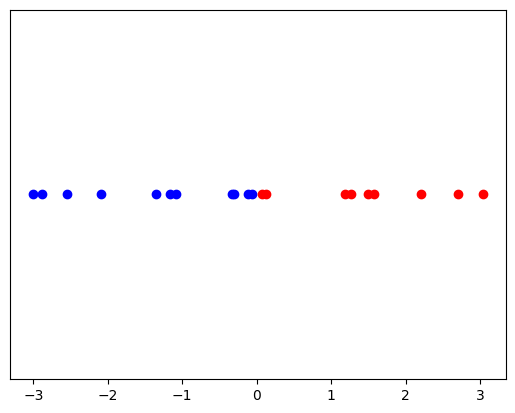

In [184]:
x, y, x0, x1 = get_seperable_data()
nb_features = 1

# Binary classification, we only keep classes 0 (blue) and 1 (red)
plt.yticks([])
plt.scatter(x0, [0]*len(x0), color='blue')
plt.scatter(x1, [0]*len(x1), color='red')

Notice how the samples are easily identified if we were to draw a vertical line at $x=0$? This line would be our classifying function! This is an example of **separable data**.

Unfortunately, real data is not so easily separable without transformation. Take a look at this dataset:

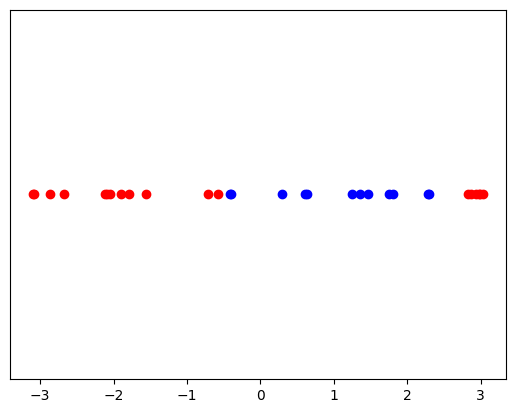

In [185]:
x0,x1 = get_non_seperable_data()
nb_features = 1

plt.yticks([])
plt.scatter(x0, [0]*len(x0), color='blue')
plt.scatter(x1, [0]*len(x1), color='red')

Notice how it is impossible to draw *one* vertical line to perfectly separate the samples into 2 classes... but what if we projected our data into a higher dimension, say the xy-plane?

Then, it would be possible to define a 2D function $y = f(x)$ to separate the data!
This is exactly what we are going to do! We will project our data in the space where quantum states live and find a classifying function!

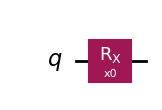

In [186]:
# Create a list of `Parameter`. Since the data points only have one feature
# there will be only one parameter in this list.
x_params = [Parameter(f'x{str(i)}') for i in range(nb_features)]

# Instanciate a quantum circuit
qc = QuantumCircuit(nb_features)

for i in range(1):
    # Data encoding using the rotation RX
    qc.rx(x_params[i], i)

qc.draw('mpl')

In [187]:
# We will be using simulators
qasm_sim = Aer.get_backend('qasm_simulator')
sv_sim = Aer.get_backend('statevector_simulator')

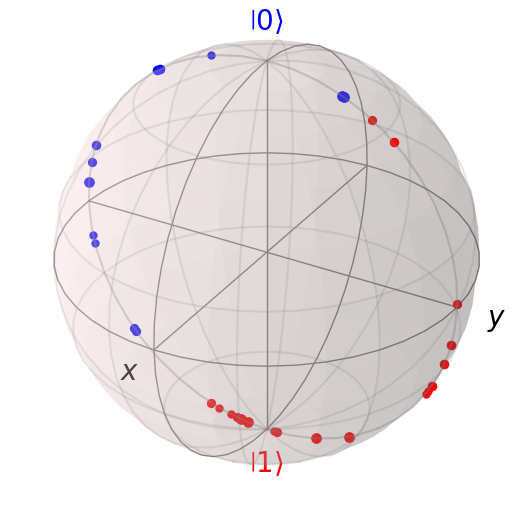

In [188]:
# Obtain the state vector corresponding to each points in the dataset
statevectors0 = get_statevector(qc, x0, x_params, sv_sim)
statevectors1 = get_statevector(qc, x1, x_params, sv_sim)

# Visualization of the dataset on the BLoch sphere
plot_bloch_visualization([statevectors0, statevectors1], ['b', 'r'])

Can you see how the samples could be divided into 2 classes easily by a plane in the Bloch sphere?

# 2. Quantum Binary Classifier
A quantum binary classifier projects classical data into a space of infinite dimensions where quantum states live, namely the Hilbert space.
Then, it iteratively builds  a classifying function in this space, to divide the data into two classes.
Finally, it outputs class labels classically.

Training a quantum classifier involves a few steps:
* Loading our classical data into the quantum computer

* Choosing an interpretation function to label the projected data after measurement

* Define and train a change of basis circuit to ensure we are measuring in the basis where the data is the most separable

* Define a loss function

* Build a hybrid training loop that makes use of classical computing to update our free parameters

We will go trough the entire pipeline and introduce you to tools available in Qiskit which may help you for the main challenge.

# 3. Iris Dataset

The Iris dataset is composed of 150 samples categorized into 3 species (Setosa, Versicolour, Virginica), i.e classes. A data sample is composed of 4 measurements (sepal length, sepal width, petal length, petal width), i.e features.

Before tackling the task at hand, we need to pre-process the data. In our case, this step involves:
* keeping only two classes

* normalizing the data

* splitting the data into a training set and a test set

In [189]:
# Experiment Parameters
nb_features = 4
nb_classes = 2
test_ratio=0.2

In [190]:
def preprocessing(test_ratio, SEED):
    # Load the Iris dataset
    iris = datasets.load_iris()

    Y = iris.target[:100] # These are the true class labels or 'targets' for every sample
    X = np.array([x / np.linalg.norm(x) for x in iris.data[:100]]) # Normalizing the data

    # The data is split into a training and test set
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=test_ratio, random_state=SEED, stratify=Y)

    
    return x_train, x_test, y_train, y_test

In [191]:
x_train, x_test, y_train, y_test = preprocessing(test_ratio, SEED)
print(f'Size of the train set: {len(x_train)}\nSize of the test set: {len(x_test)}')  

Size of the train set: 80
Size of the test set: 20


# 4. Data Embedding
Data embedding is the crucial step in the QML pipeline consisting of feeding the classical data into the quantum computer. In other words, we want to establish a 1-to-1 mapping between a classical datapoint and a quantum state.
This mapping is realized by a quantum circuit composed of parametrized gates. The value of each parameter is related to the classical data being fed.

There are many ways to build data embedding circuits. Qiskit has some methods that are worth researching if you want to experiment. Here's a few:
* `RawFeatureVector`

* `ZZFeatureMap`

* `PauliFeatureMap`

In this notebook, we will use the simple **angle embedding** scheme where we encode each feature of a data vector into the angle argument of a parametrized quantum rotation gate.

You have already seen it in action in the Binary Classification section.

Let's define a function which applies **angle embedding** to a feature vector.

In [192]:
def angle_embedding(x, nb_features):  
    """
    Qubit - or rotation - encoding in RX gates.

    :param x: The feature vector parametrizing the RX gates.
                        The number of qubit in the circuit should be equal to the number
                        of feature in the input vector. 
    :param nb_features: Number of features
    :return: The quantum circuit with the embedding layer. 
    """
    qc = QuantumCircuit(nb_features)
    
    if qc.num_qubits != len(x):
        raise ValueError('Number of features must match number of qubits')

    for i in range(qc.num_qubits):
        qc.rx(x[i], i)

    return qc

Let's start by embedding a single feature vector into a quantum state

Features for the first datapoint: [0.776114   0.54974742 0.30721179 0.03233808]


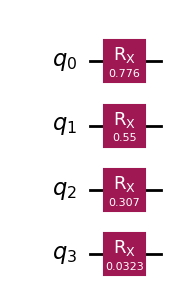

In [193]:
print('Features for the first datapoint:', x_train[0])

# Add the data embedding layer
emb_circuit = angle_embedding(x_train[0], nb_features)

emb_circuit.draw("mpl")

# 5. Measuring the Probability Distributions
Now that we have transformed our data into quantum states, we need to extract the class labels in some way.
Taking a quantum measurement is a way to collapse the state into either $|0\rangle$ or $|1\rangle$ which is exactly what we need for binary classification.

Recall that the result of a quantum measurement is probabilistic. We need to take many measurements to say whether a quantum state is more likely to collapse into class 0 or 1. Once we have repeated this process many times, we are left with the probabilities for each data vector to either result in state $|0\rangle$ or $|1\rangle$.

Finally, we just need to conclude that if the probability of collapsing into $|0\rangle$ is higher than 0.5, then it is identified as belonging to class 0, or 1 otherwise.

The following figure is a quick visual summary:
![lab3.png](lab3.png)


* $h_T$: the quantum classifier

* $\vec{x}$: the data vector

* $\phi$: the embedding quantum circuit

* $|\phi(\vec{x})\rangle$: the quantum state representing the data sample after embedding

* $N$: number of measurements or 'shots' for one data vector

* $m$: measurement result

* $p_0(\vec{x})$ and $p_1(\vec{x})$ the probabilities for one data vector to have measurement result 0 or 1

* $\tilde{y}$: the predicted class label

In [194]:
qasm_sim = Aer.get_backend('qasm_simulator')
sv_sim = Aer.get_backend('statevector_simulator')

In [195]:
shots = 1024


def get_measurement_outcomes(data, emb_circuit, rot_circuit=None):
    """
    Run the circuit of the binary quantum classifier for all the data vectors of a dataset.

    :param data:        Dataset to classify
    :param emb_circuit: Angle embedding circuit.
    :param rot_circuit: Circuit defining the measurement basis.
                        Defaults to the computational basis (Z)

    :return: A list of measurement results, one per data vector in the dataset.
    """
    # Add the circuit defining the measurement basis.
    if rot_circuit != None:
        emb_circuit = emb_circuit.compose(rot_circuit)

    circuits = []
    # For each datapoint in the dataset
    for x_i in data:
        x_params = emb_circuit.parameters
        # Dictionary associating one data feature to one parameter in the circuit
        x_params_dict = {p:v for (p,v) in zip(x_params, x_i)}
        # Replace the circuit parameters by their associated values
        gqc = emb_circuit.assign_parameters(x_params_dict)
        # Add the measurement instruction for all qubits
        gqc.measure_all()
        circuits.append(gqc)

    # Run the circuit "N" times (determined by the number of shots)
    result = qasm_sim.run(circuits, shots=shots).result()
    counts = result.get_counts()

    return counts

In [196]:
counts = get_measurement_outcomes(x_train, emb_circuit)

# Show the first 3 count dictionary in counts
for count in counts[:3]:
    print(count)

{'0110': 2, '0100': 19, '0001': 135, '0101': 2, '0011': 11, '0010': 57, '0000': 798}
{'0101': 4, '0110': 1, '0001': 132, '0100': 24, '0011': 12, '0010': 62, '0000': 789}
{'0101': 2, '0100': 17, '0001': 135, '0111': 1, '0011': 17, '0010': 63, '0000': 789}


### Interpretation Function
We need a rule to interpret measurement results as beloning to class 0 or 1. For instance, what class does the result '0101' belongs to?
A simple interpretation function is to let the parity of the measurement result decide the class label.
'0101' has a parity of 0, hence it belongs to class 0 according to our interpretation scheme.
There are other schemes that can be used, feel free to explore!

In [197]:
def parity(x):
    return x.count('1') % 2

In [198]:
def get_probabilities_from_counts(counts):
    """
    Compute the probabilities of belonging to class 0 or 1 according to 
    the measurement results of a binary classifier.
    """
    num_classes = 2
    probs = []

    # For each measurement results corresponding to a datapoint in the dataset
    for dict_meas in counts:
        
        # We count the number of times we observed 0 and 1 respectively
        indiv_probs = np.zeros(num_classes)
        for k, v in dict_meas.items():
            label = parity(k)
            if label == 0:
                indiv_probs[0] = indiv_probs[0] + v
            else:
                indiv_probs[1] = indiv_probs[1] + v

        # We translate the number of observation instances of 0 and 1 into probabilities
        indiv_probs /= shots
        probs.append(indiv_probs)

    return np.round(probs, decimals=3)

In [199]:
probs = get_probabilities_from_counts(counts)
probs.shape

(80, 2)

In [200]:
def get_accuracy(probs, targets):
    """
    Compute the accuracy obtained by the binary classifier

    :param probs:   The probability predicted by the classifier for each data vector to be
                    in class 0 or 1.

    :param targets: List of labels.

    :return: classifier precision.
    """
    # The predicted class correponds to the one with the highest probability
    predict = np.argmax(probs, axis=1)
    targets = np.array(targets).reshape(predict.shape)
    # We count the number of times the prediction corresponds to the label and we divide
    # by the total number of predictions.
    accuracy = np.sum(predict == targets) / len(predict)
    
    return accuracy

In [201]:
accuracy = get_accuracy(probs, y_train)
print(f'>\n> The accuracy of our classifier is {accuracy*100}%.\n>')

>
> The accuracy of our classifier is 50.0%.
>


As you can see, the accuracy is really not good! We are basically guessing the label randomly, something is missing...

# 6. Change of Basis Circuit
It turns out that projecting our data into the Hilbert space, taking quantum measurements and interpreting them is not enough!
Indeed, we are lacking a way to truly discriminate between the different classes *within* the quantum space.
Let's look at a simple case that will shed some light on the problem and its solution.

In [202]:
x, y, x0, x1 = get_seperable_data()
nb_features = 1

#  1 parameter
x_params = [Parameter(f'x{str(i)}') for i in range(nb_features)]
# Angle embedding circuit
qc = angle_embedding(x_params, nb_features)

counts = get_measurement_outcomes(x, qc)

probs = get_probabilities_from_counts(counts)

accuracy = get_accuracy(probs, y)
print(f'>\n> The accuracy of our classifier is {accuracy*100}%.\n>')



>
> The accuracy of our classifier is 25.0%.
>


In [203]:
statevectors0 = get_statevector(qc, x0, x_params, sv_sim)
statevectors1 = get_statevector(qc, x1, x_params, sv_sim)

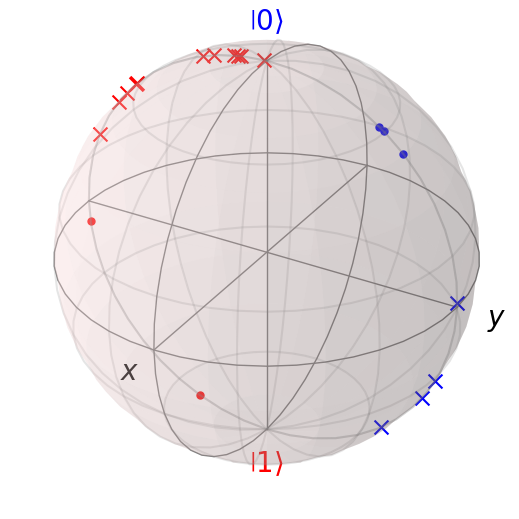

In [204]:
predict = np.argmax(probs, axis=1)
plot_bloch_visualization([statevectors0, statevectors1], x=x, x0=x0, x1=x1, score=(predict==np.array(y).reshape(predict.shape)))

Recall that when we measure a quantum state we do so in the computational basis which is equivalent to measuring along the Z-axis on the Bloch sphere.

Unfortunately, in this specific case, the projected data cannot be distinguished between classes 0 and 1 along the Z-axis.

Now, if we were to measure along the Y-axis, that would be a different story!

In [205]:
# Measure along the Y-axis
qc_ybasis = QuantumCircuit(1)
qc_ybasis.sdg(0)
qc_ybasis.h(0)

In [206]:


counts = get_measurement_outcomes(x, qc, qc_ybasis)

probs = get_probabilities_from_counts(counts)

accuracy = get_accuracy(probs, y)
print(f'>\n> The accuracy of our classifier is {accuracy*100}%.\n>')

>
> The accuracy of our classifier is 100.0%.
>


### A Few Words
In general, we do not know the structure of **the change of basis circuit**.
We must use an *ansatz*, a parametrized circuit with a specific structure, that we must train in order to achieve optimal measurement results. Many ansatzs are readily available in Qiskit.
For instance, you can use the `TwoLocal` ansatz which is a "parameterized circuit consisting of alternating rotation layers and entanglement layers" ([documentation](https://quantum.cloud.ibm.com/docs/fr/api/qiskit/qiskit.circuit.library.TwoLocal)).

The optimal measurements are the ones that minimizes the classification error, i.e the number of misclassified samples.

# 7. Train a Quantum Classifier using Qiskit Machine Learning
Qiskit already has tools to easily implement a training loop in the `qiskit-machine-learning` package, as well as a class to implement a quantum classifier using the `Estimator` and `Sampler` primitives.

We will use the `SamplerQNN` that takes data vectors as inputs, and outputs class labels after measuring quantum circuits. The pipeline is exactly the same as we followed in the previous sections.

Finally, we will train our quantum classifier using the `NeuralNetwork` class.

## Your Task
You must assemble the whole QML pipeline using `qiskit-machine-learning` to build a quantum binary classifier.

**You need to show to a mentor that you can achieve an accuracy higher than 98% to validate this sidequest!**

In [207]:
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import zz_feature_map, n_local
from qiskit_algorithms.optimizers import COBYLA

In [208]:
# Experiment Parameters
nb_features = 4
nb_classes = 2
test_ratio=0.2

# Splitting the data in training set and test set
x_train, x_test, y_train, y_test = preprocessing(test_ratio, SEED)

In [209]:
# Preparing the recipes to build a SamplerQNN

# Data embedding circuit
# TODO: Use a different embedding than angle embedding. For instance, try a feature map available in Qiksit.  
emb_circuit = zz_feature_map(feature_dimension=nb_features, reps=2)

# Circuit to learn the measurement basis
# TODO: Use an ansatz available in Qiksit to build a parametrized change of basis circuit. For instance, TwoLocal.
ansatz = n_local(
    num_qubits=nb_features,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks="cz",
    entanglement="linear",
    reps=2,
    parameter_prefix="θ",
)

qc = emb_circuit.compose(ansatz)


# Interpretation function: parity
# TODO
def interpretation_func(measured_integer):
    return bin(measured_integer).count("1") % 2

# Random initialization of the QNN weights
np.random.seed(SEED)
initial_weights = np.random.rand(ansatz.num_parameters) 

# Initialize the classical optimizer used to update the circuit parameters
# TODO: Use an optimizer avaialble in qiskit machine learning or any other!
num_iter = 30
optimizer = COBYLA(maxiter=num_iter)

# Current Qiskit versions use Sampler V2 primitives.
sampler = StatevectorSampler(seed=SEED)


In [210]:
## Create a QNN
# TODO
sampler_qnn = SamplerQNN(
    circuit=qc,
    sampler=sampler,
    input_params=list(emb_circuit.parameters),
    weight_params=list(ansatz.parameters),
    interpret=interpretation_func,
    output_shape=nb_classes,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


### Training of the Classifier with `Neural Network Classifier`

In [211]:
# Instanciate the class used to train the quantum classifier using NeuralNetworkClassifier
# TODO
circuit_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn,
    optimizer=optimizer,
    initial_point=initial_weights,
)

# Train the model with the fit method
# TODO
circuit_classifier.fit(x_train, y_train)

In [212]:
# Compute model accuracy on the training and test datasets with the score method
# TODO
train_acc = circuit_classifier.score(x_train, y_train)
test_acc = circuit_classifier.score(x_test, y_test)

print(f">\n> Accuracy on the training set: {train_acc}\n> Accuracy on the test set: {test_acc}\n>")

>
> Accuracy on the training set: 1.0
> Accuracy on the test set: 1.0
>


### Going Further and Beyond
We have but seen a very simple pipeline to build a vanilla quantum classifier. There are many hyperparameters to explore in order to improve performance or give more flexibility to your models. Here is a short list of them that are worth looking up:
* optimizers (SPSA, Adam, etc )
* measurement interpretation function
* more expressive data embedding
* QNN weight initialization schemes
* `EstimatorQNN`

*Mise à jour: Avril 2026*